In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import os


In [2]:
fp = "/Users/alec/Desktop/RNAanalysis/Datacsv.csv"
df = pd.read_csv(fp)
df.head()

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,1,476.838460,6.088545,0.117768,51.699649,0.0,0.0
1,2,539.439737,-4.380346,0.109281,-40.083180,0.0,0.0
2,3,1180.420816,-3.727957,0.077039,-48.390484,0.0,0.0
3,4,53542.133222,-4.770429,0.052575,-90.736018,0.0,0.0
4,5,307.988944,-4.142868,0.102250,-40.517031,0.0,0.0


In [3]:
df = df[df['pvalue'] != 'NA']

In [4]:
df.dropna(inplace=True)

In [5]:
print(df)

     Unnamed: 0      baseMean  log2FoldChange     lfcSE       stat    pvalue  \
0             1    476.838460        6.088545  0.117768  51.699649  0.000000   
1             2    539.439737       -4.380346  0.109281 -40.083180  0.000000   
2             3   1180.420816       -3.727957  0.077039 -48.390484  0.000000   
3             4  53542.133222       -4.770429  0.052575 -90.736018  0.000000   
4             5    307.988944       -4.142868  0.102250 -40.517031  0.000000   
..          ...           ...             ...       ...        ...       ...   
304         305      1.610531       -0.170064  3.176564  -0.053537  0.957304   
305         306      1.432812       -0.099006  2.409736  -0.041086  0.967227   
306         307      0.443943       -0.106359  2.921120  -0.036410  0.970955   
307         308     20.336889        0.005974  0.302636   0.019741  0.984250   
312         313      6.129374        0.003305  0.791920   0.004173  0.996670   

         padj  
0    0.000000  
1    0.

In [6]:
df['neg_log10_padj'] = -np.log10(df['padj'])


/Users/alec/miniconda3/envs/RNAanalysis/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [7]:
df

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,neg_log10_padj
0,1,476.838460,6.088545,0.117768,51.699649,0.000000,0.000000,inf
1,2,539.439737,-4.380346,0.109281,-40.083180,0.000000,0.000000,inf
2,3,1180.420816,-3.727957,0.077039,-48.390484,0.000000,0.000000,inf
3,4,53542.133222,-4.770429,0.052575,-90.736018,0.000000,0.000000,inf
4,5,307.988944,-4.142868,0.102250,-40.517031,0.000000,0.000000,inf
...,...,...,...,...,...,...,...,...
304,305,1.610531,-0.170064,3.176564,-0.053537,0.957304,0.974025,0.011430
305,306,1.432812,-0.099006,2.409736,-0.041086,0.967227,0.979362,0.009057
306,307,0.443943,-0.106359,2.921120,-0.036410,0.970955,0.979362,0.009057
307,308,20.336889,0.005974,0.302636,0.019741,0.984250,0.988492,0.005027


In [8]:
df = df[df['padj'] != 0]

In [9]:
df

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,neg_log10_padj
5,6,714.665547,-2.648772,0.082177,-32.232616,6.165085e-228,2.394108e-226,225.620856
6,7,167.066610,-6.258266,0.224484,-27.878450,4.870150e-171,1.621064e-169,168.790200
7,8,700.229442,3.662540,0.135590,27.011819,1.073589e-160,3.126829e-159,158.504896
8,9,191.317147,-3.762151,0.152123,-24.731023,4.961697e-135,1.284528e-133,132.891256
9,10,608.247501,-4.938409,0.199881,-24.706714,9.057781e-135,2.110463e-133,132.675622
...,...,...,...,...,...,...,...,...
304,305,1.610531,-0.170064,3.176564,-0.053537,9.573040e-01,9.740255e-01,0.011430
305,306,1.432812,-0.099006,2.409736,-0.041086,9.672274e-01,9.793618e-01,0.009057
306,307,0.443943,-0.106359,2.921120,-0.036410,9.709553e-01,9.793618e-01,0.009057
307,308,20.336889,0.005974,0.302636,0.019741,9.842496e-01,9.884921e-01,0.005027


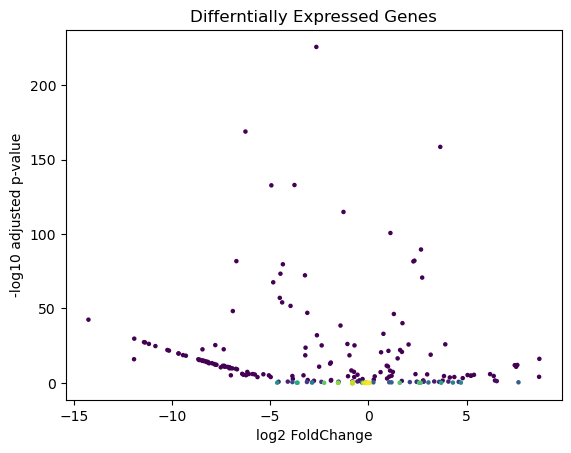

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(df['log2FoldChange'], df['neg_log10_padj'], c=df['pvalue'], s=5, cmap='viridis')
ax.set_xlabel('log2 FoldChange')
ax.set_ylabel('-log10 adjusted p-value')
ax.set_title('Differntially Expressed Genes')
plt.show()

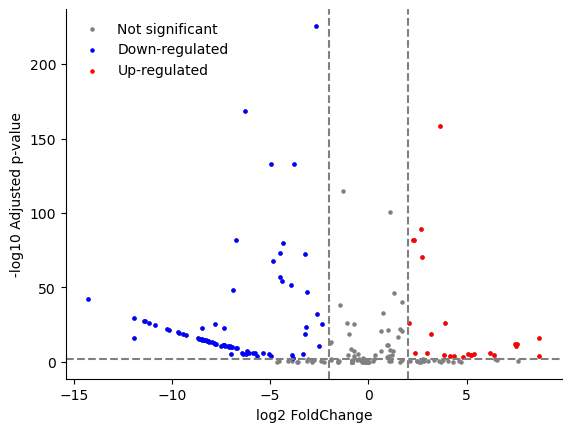

In [26]:
fig, ax = plt.subplots()
marker_size = 5
ax.scatter(df['log2FoldChange'],-np.log10(df['padj']),s=marker_size,label="Not significant",c="grey")

# highlight down- or up- regulated genes
down = df[(df['log2FoldChange']<=-2)&(df['padj']<=0.01)]
up = df[(df['log2FoldChange']>=2)&(df['padj']<=0.01)]

ax.scatter(down['log2FoldChange'],-np.log10(down['padj']),s=marker_size,label="Down-regulated",c="blue")
ax.scatter(up['log2FoldChange'],-np.log10(up['padj']),s=marker_size,label="Up-regulated",c="red")

ax.set_xlabel("log2 FoldChange")
ax.set_ylabel("-log10 Adjusted p-value")
ax.axvline(-2,color="grey",linestyle="--")
ax.axvline(2,color="grey",linestyle="--")
ax.axhline(2,color="grey",linestyle="--")
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("Volcano Plot 2.png", dpi=600)